<a href="https://colab.research.google.com/github/QwertyC-137/Gaussian-and-Binomial-Distributions/blob/main/template_loading_and_testing_files.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#load in files from collab
#obtain random 3 indexes from each file
#look for those indexes in hdf files and return them if they match



In [ ]:
import matplotlib.pyplot as plt


In [ ]:
directory='/content/drive/MyDrive/Skin_cancer_classifier'

In [ ]:
directories = {
    "train_cancer": "/content/drive/MyDrive/Skin_cancer_classifier/train/1",
    "train_not_cancer": "/content/drive/MyDrive/Skin_cancer_classifier/train/0",
    "test_1_cancer": "/content/drive/MyDrive/Skin_cancer_classifier/test_1/1",
    "test_1_not_cancer": "/content/drive/MyDrive/Skin_cancer_classifier/test_1/0",
    "test_2_cancer": "/content/drive/MyDrive/Skin_cancer_classifier/test_2/1",
    "test_2_not_cancer": "/content/drive/MyDrive/Skin_cancer_classifier/test_2/0",
    "validation_cancer": "/content/drive/MyDrive/Skin_cancer_classifier/validation/1",
    "validation_not_cancer": "/content/drive/MyDrive/Skin_cancer_classifier/validation/0"
}
def get_file_path(directory):
    for file_name in os.listdir(directory):
        file_path = os.path.join(directory, file_name)
        return file_path

# Get the file paths for each directory
file_paths = {key: get_file_path(directory) for key, directory in directories.items()}

# Print the file paths
for key, file_path in file_paths.items():
    print(f"{key}= '{file_path}'")

train_cancer= '/content/drive/MyDrive/Skin_cancer_classifier/train/1/train_cancer_images.hdf5'
train_not_cancer= '/content/drive/MyDrive/Skin_cancer_classifier/train/0/train_non_cancer_images.hdf5'
test_1_cancer= '/content/drive/MyDrive/Skin_cancer_classifier/test_1/1/test_cancer_final_images.hdf5'
test_1_not_cancer= '/content/drive/MyDrive/Skin_cancer_classifier/test_1/0/test_non_cancer_final_images.hdf5'
test_2_cancer= '/content/drive/MyDrive/Skin_cancer_classifier/test_2/1/remaining_cancer_images.hdf5'
test_2_not_cancer= '/content/drive/MyDrive/Skin_cancer_classifier/test_2/0/remaining_non_cancer_images.hdf5'
validation_cancer= '/content/drive/MyDrive/Skin_cancer_classifier/validation/1/validation_cancer_images.hdf5'
validation_not_cancer= '/content/drive/MyDrive/Skin_cancer_classifier/validation/0/validation_non_cancer_images.hdf5'


In [ ]:
train_cancer= '/content/drive/MyDrive/Skin_cancer_classifier/train/1/train_cancer_images.hdf5'
train_not_cancer= '/content/drive/MyDrive/Skin_cancer_classifier/train/0/train_non_cancer_images.hdf5'
test_1_cancer= '/content/drive/MyDrive/Skin_cancer_classifier/test_1/1/test_cancer_final_images.hdf5'
test_1_not_cancer= '/content/drive/MyDrive/Skin_cancer_classifier/test_1/0/test_non_cancer_final_images.hdf5'
test_2_cancer= '/content/drive/MyDrive/Skin_cancer_classifier/test_2/1/remaining_cancer_images.hdf5'
test_2_not_cancer= '/content/drive/MyDrive/Skin_cancer_classifier/test_2/0/remaining_non_cancer_images.hdf5'
validation_cancer= '/content/drive/MyDrive/Skin_cancer_classifier/validation/1/validation_cancer_images.hdf5'
validation_not_cancer= '/content/drive/MyDrive/Skin_cancer_classifier/validation/0/validation_non_cancer_images.hdf5'

In [ ]:
hdf5_paths = {
    'train_cancer': train_cancer,
    'train_non_cancer': train_not_cancer,
    'test_cancer_final': test_1_cancer,
    'test_non_cancer_final': test_1_not_cancer,
    'remaining_cancer': test_2_cancer,
    'remaining_non_cancer': test_2_not_cancer,
    'validation_cancer': validation_cancer,
    'validation_non_cancer': validation_not_cancer
}

In [ ]:
import os
import h5py
import numpy as np
from PIL import Image
import random
import pandas as pd

In [ ]:
file_list=os.listdir(directory)

In [ ]:
df_names=[]

In [ ]:
for filename in file_list:
  if filename.endswith('.csv'):
    read_path=os.path.join(directory,filename)
    df=pd.read_csv(read_path)
    var_name=filename.replace('label_','').replace('.csv','')
    globals()[var_name]=df
    df_names.append(var_name)
    print(var_name)

validation_non_cancer
test_cancer_final
remaining_cancer
validation_cancer
test_non_cancer_final
train_non_cancer
remaining_non_cancer
train_cancer


In [ ]:
index_list=[]

In [ ]:
for var_name in df_names:
   df=globals()[var_name]
   globals()[f'{var_name}_id_list']=df['isic_id'].tolist()
   index_list.append(f'{var_name}_id_list')
   print(f'{var_name}_id_list')

validation_non_cancer_id_list
test_cancer_final_id_list
remaining_cancer_id_list
validation_cancer_id_list
test_non_cancer_final_id_list
train_non_cancer_id_list
remaining_non_cancer_id_list
train_cancer_id_list


In [ ]:
print(test_cancer_final_id_list)

['ISIC_4079957', 'ISIC_9152373', 'ISIC_7235721', 'ISIC_8717913', 'ISIC_2299573', 'ISIC_6395169', 'ISIC_3744161', 'ISIC_1211710', 'ISIC_1721956', 'ISIC_0528190', 'ISIC_1705108', 'ISIC_3890780', 'ISIC_9188287', 'ISIC_3813551', 'ISIC_4217775', 'ISIC_2364514', 'ISIC_1071408', 'ISIC_7800702', 'ISIC_3005303', 'ISIC_5068210', 'ISIC_0814829', 'ISIC_1186361', 'ISIC_0664841', 'ISIC_9420821', 'ISIC_9762220', 'ISIC_3585149', 'ISIC_4425681', 'ISIC_4586629', 'ISIC_0467830', 'ISIC_0699524']


In [ ]:
random_indexes = {}
for index_file in index_list:
    random_indexes[index_file] = random.sample(globals()[index_file], 3)
    print(f'Random samples from {index_file}: {random_indexes[index_file]}')

Random samples from validation_non_cancer_id_list: ['ISIC_0621012', 'ISIC_5672203', 'ISIC_5535474']
Random samples from test_cancer_final_id_list: ['ISIC_0528190', 'ISIC_5068210', 'ISIC_1071408']
Random samples from remaining_cancer_id_list: ['ISIC_5832006', 'ISIC_6246414', 'ISIC_2396582']
Random samples from validation_cancer_id_list: ['ISIC_0332355', 'ISIC_5985180', 'ISIC_8491708']
Random samples from test_non_cancer_final_id_list: ['ISIC_4931011', 'ISIC_6412388', 'ISIC_1533137']
Random samples from train_non_cancer_id_list: ['ISIC_6600027', 'ISIC_2410557', 'ISIC_4205444']
Random samples from remaining_non_cancer_id_list: ['ISIC_3230220', 'ISIC_3991548', 'ISIC_1173036']
Random samples from train_cancer_id_list: ['ISIC_6798815', 'ISIC_7188117', 'ISIC_1662809']


In [ ]:

def get_matching_images_from_hdf5(hdf5_filepath, index_list):
    with h5py.File(hdf5_filepath, 'r') as hdf:
        images = []
        for idx in index_list:
            if idx in hdf:
                image_data = hdf[idx][()]
                images.append((idx, image_data))
            else:
                print(f"Warning: Index {idx} not found in {hdf5_filepath}")
        return images

# Retrieve matching images for each dataset
matching_images = {}
for var_name in df_names:
    hdf5_path = hdf5_paths[var_name]
    indexes = random_indexes[f'{var_name}_id_list']
    matching_images[var_name] = get_matching_images_from_hdf5(hdf5_path, indexes)
    print(f'Matching images for {var_name}: {len(matching_images[var_name])} images found')

Matching images for validation_non_cancer: 3 images found
Matching images for test_cancer_final: 3 images found
Matching images for remaining_cancer: 3 images found
Matching images for validation_cancer: 3 images found
Matching images for test_non_cancer_final: 3 images found
Matching images for train_non_cancer: 3 images found
Matching images for remaining_non_cancer: 3 images found
Matching images for train_cancer: 3 images found


In [ ]:
from PIL import Image
import io

In [ ]:
def display_images(images):
    for idx, image_data in images:
        print(f"Index: {idx}")
        img = Image.open(io.BytesIO(image_data))
        img.show()
        plt.imshow(img)
        plt.show()

Displaying images for validation_non_cancer
Index: ISIC_0621012


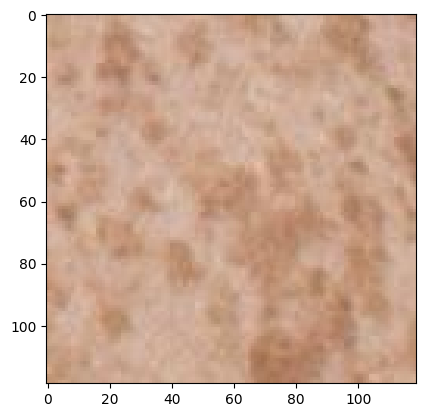

Index: ISIC_5672203


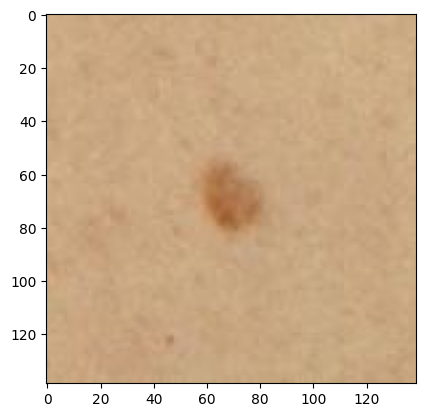

Index: ISIC_5535474


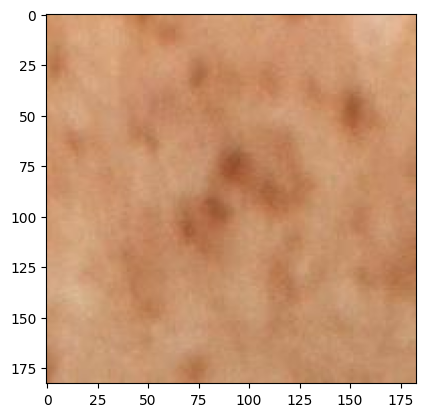

Displaying images for test_cancer_final
Index: ISIC_0528190


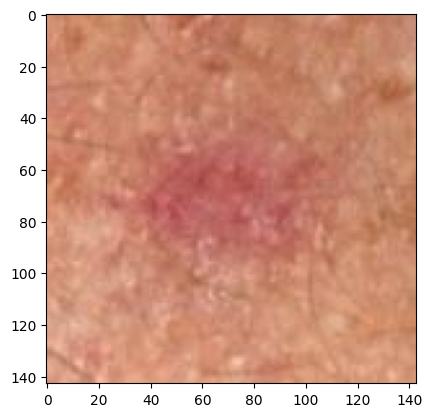

Index: ISIC_5068210


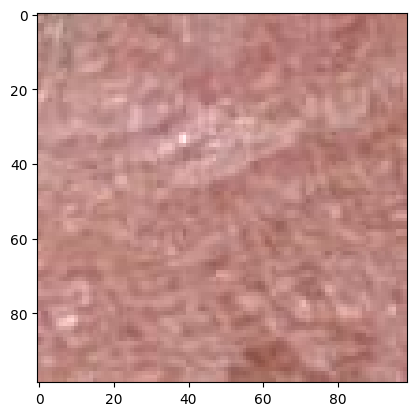

Index: ISIC_1071408


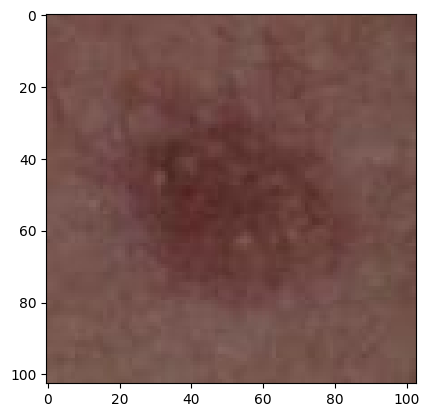

Displaying images for remaining_cancer
Index: ISIC_5832006


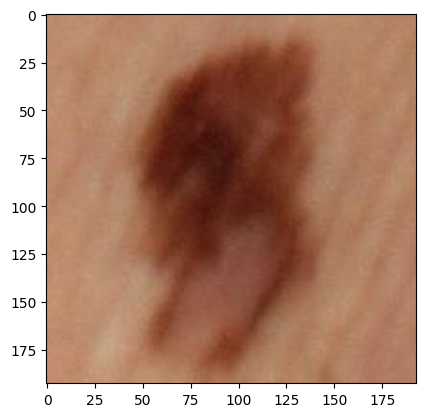

Index: ISIC_6246414


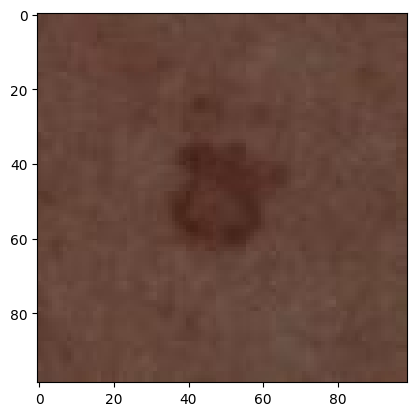

Index: ISIC_2396582


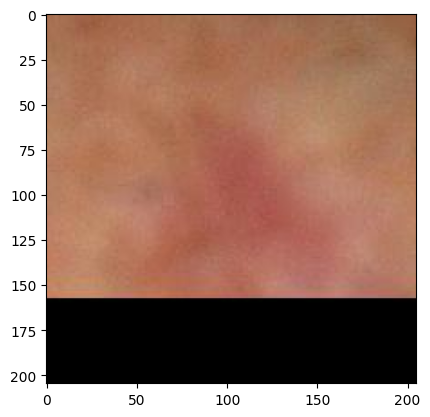

Displaying images for validation_cancer
Index: ISIC_0332355


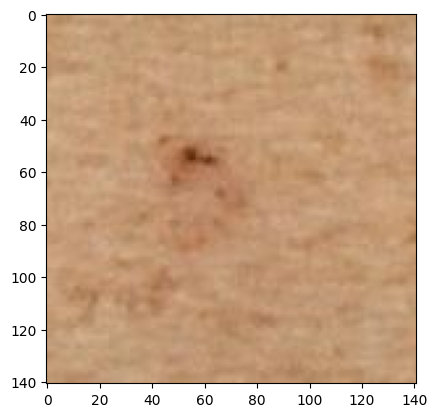

Index: ISIC_5985180


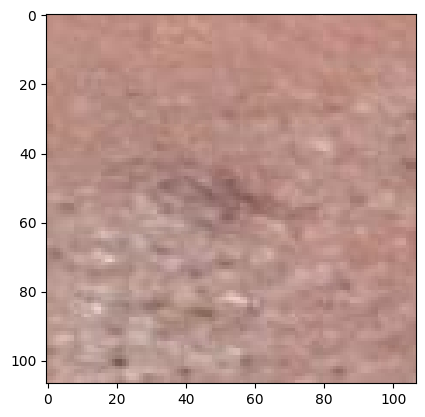

Index: ISIC_8491708


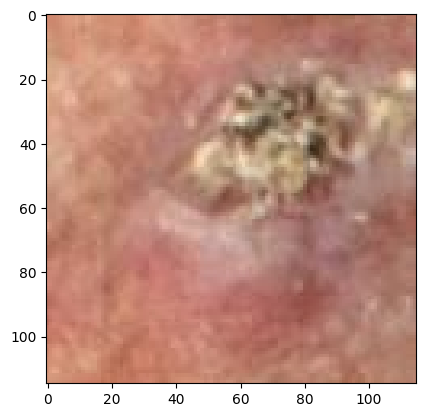

Displaying images for test_non_cancer_final
Index: ISIC_4931011


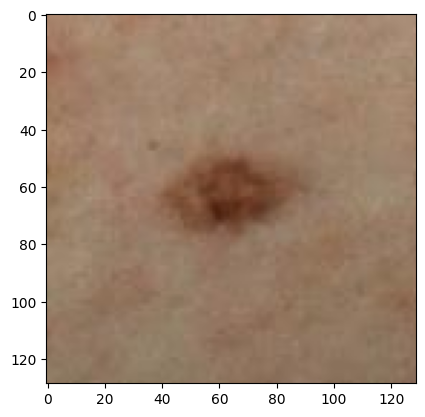

Index: ISIC_6412388


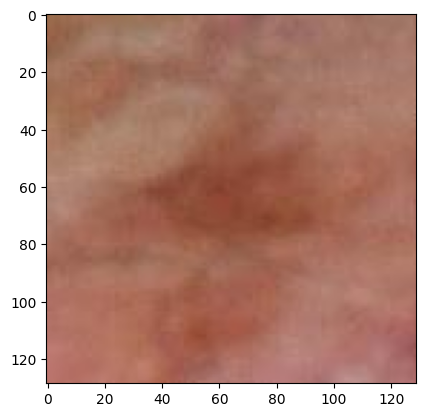

Index: ISIC_1533137


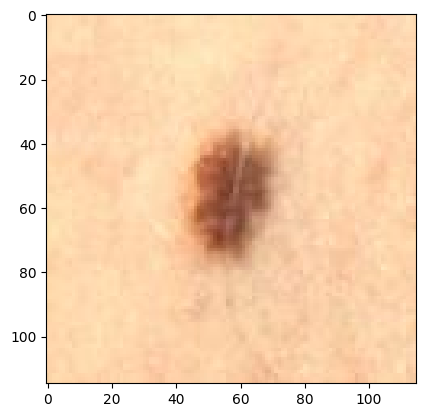

Displaying images for train_non_cancer
Index: ISIC_6600027


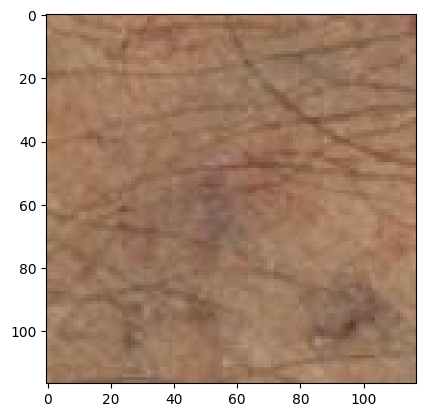

Index: ISIC_2410557


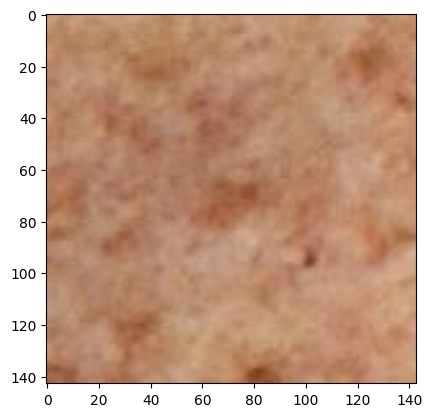

Index: ISIC_4205444


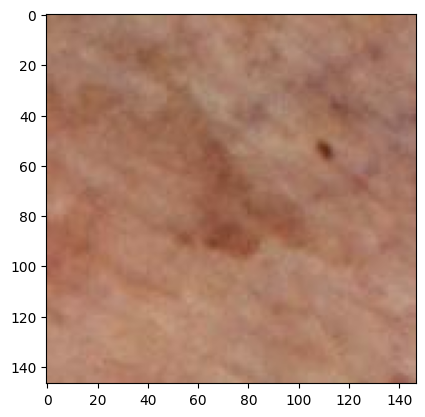

Displaying images for remaining_non_cancer
Index: ISIC_3230220


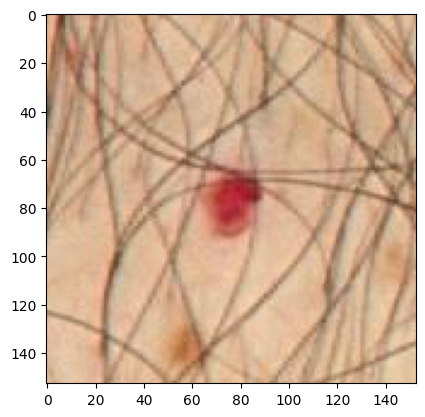

Index: ISIC_3991548


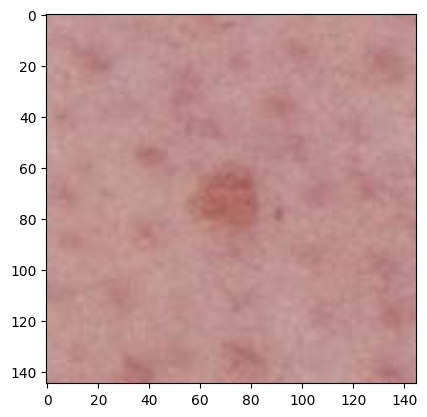

Index: ISIC_1173036


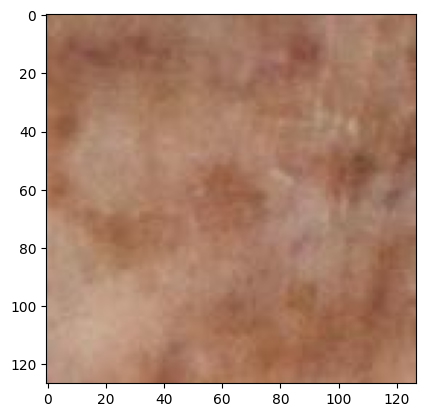

Displaying images for train_cancer
Index: ISIC_6798815


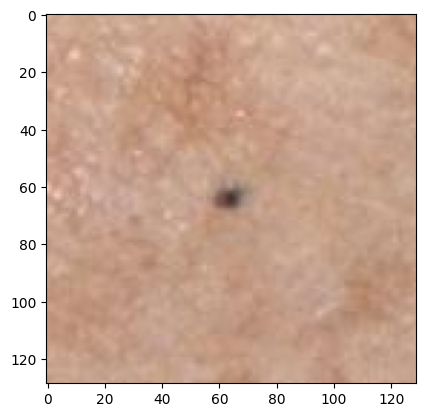

Index: ISIC_7188117


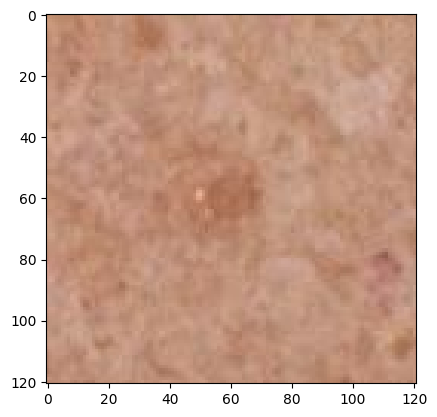

Index: ISIC_1662809


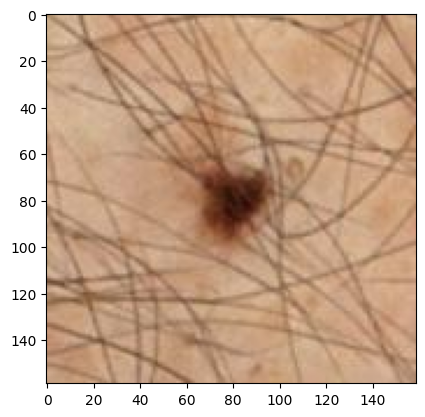

In [ ]:
for var_name, images in matching_images.items():
    print(f"Displaying images for {var_name}")
    display_images(images)